In [ ]:
# ============================================
# LOAD SAVED MODEL (Skip training if possible)
# ============================================
# Run this cell first if you want to load a previously trained model.

from pathlib import Path
import os
import random
import shutil
import ssl
from urllib.parse import urlparse
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import models

try:
    import certifi
except ImportError:
    certifi = None

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name.lower() == 'year3' and (PROJECT_DIR.parent / 'gen1').exists():
    PROJECT_DIR = (PROJECT_DIR.parent / 'gen1').resolve()
elif PROJECT_DIR.name.lower() != 'gen1' and (PROJECT_DIR / 'gen1').exists():
    PROJECT_DIR = (PROJECT_DIR / 'gen1').resolve()
else:
    PROJECT_DIR = PROJECT_DIR.resolve()

MODEL_PATH = PROJECT_DIR / 'pokemon_model_gen1_resnet50.pth'
CLASSES_PATH = PROJECT_DIR / 'gen1_classes.json'
DATASET_DIRNAME = 'PokemonData'
IMG_SIZE = 224
NUM_CLASSES = 150
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 15
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
USE_PRETRAINED_WEIGHTS = True

CA_BUNDLE = certifi.where() if certifi is not None else None
if CA_BUNDLE is not None:
    os.environ['SSL_CERT_FILE'] = CA_BUNDLE
    os.environ['REQUESTS_CA_BUNDLE'] = CA_BUNDLE
    os.environ['CURL_CA_BUNDLE'] = CA_BUNDLE
    print(f'Configured SSL CA bundle: {CA_BUNDLE}')
else:
    print('certifi is not installed; HTTPS downloads will rely on system certificates.')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
)


def resolve_dataset_root(dirname=DATASET_DIRNAME):
    candidates = [
        PROJECT_DIR / dirname,
        PROJECT_DIR.parent / dirname,
        PROJECT_DIR / 'archive' / dirname,
        PROJECT_DIR.parent / 'archive' / dirname,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate.resolve()
    return candidates[0].resolve()


def download_weight_file(url):
    checkpoint_dir = Path(torch.hub.get_dir()) / 'checkpoints'
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_dir / Path(urlparse(url).path).name

    if checkpoint_path.exists():
        return checkpoint_path

    ssl_context = ssl.create_default_context(cafile=CA_BUNDLE) if CA_BUNDLE is not None else None
    with urlopen(url, context=ssl_context) as response, checkpoint_path.open('wb') as file_handle:
        shutil.copyfileobj(response, file_handle)

    return checkpoint_path


def create_resnet50_model(num_classes, use_pretrained=True):
    model = models.resnet50(weights=None)

    if use_pretrained:
        try:
            weights = models.ResNet50_Weights.DEFAULT
            checkpoint_path = download_weight_file(weights.url)
            state_dict = torch.load(checkpoint_path, map_location='cpu')
            model.load_state_dict(state_dict)
            print(f'Loaded pretrained weights from {checkpoint_path}')
        except Exception as exc:
            print(f'Warning: could not load pretrained weights ({exc}). Falling back to random init.')

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

DATASET_ROOT = resolve_dataset_root()

if MODEL_PATH.exists():
    print(f'Found saved model at {MODEL_PATH}')
    model = create_resnet50_model(NUM_CLASSES, use_pretrained=False).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f'Model loaded successfully on {device}')
else:
    print(f'No saved model found at {MODEL_PATH}')
    print('Run the training cells below to train and save a new model.')
    model = None

print(f'Project directory: {PROJECT_DIR}')
print(f'Default dataset root: {DATASET_ROOT}')
print(f'Using device: {device}')

Configured SSL CA bundle: /Users/isaaclau128/The-Pokedex-Project/.venv/lib/python3.13/site-packages/certifi/cacert.pem
No saved model found at pokemon_model_gen1_resnet50.pth
Run the training cells below to train and save a new model.
Default dataset root: /Users/isaaclau128/The-Pokedex-Project/Year3/PokemonData
Using device: mps


1. Prerequisites

In [2]:
import json
from collections import Counter
from datetime import datetime
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageFile
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
# Run this once if your notebook environment is missing any packages.
# %pip install seaborn scikit-learn kaggle

2. Importing the dataset

In [4]:
# Uncomment these commands if you want the notebook to download the Kaggle dataset for you.
# Make sure your Kaggle API credentials are configured first.
# !kaggle datasets download -d lantian773030/pokemonclassification -p .
# !unzip -o pokemonclassification.zip

In [ ]:
dataset_root = resolve_dataset_root()
print(f'Dataset root: {dataset_root}')

if not dataset_root.exists():
    raise FileNotFoundError(
        'PokemonData folder not found. Download the Kaggle dataset and place the PokemonData folder '
        'either in the workspace root or inside gen1.'
    )

class_dirs = sorted([path for path in dataset_root.iterdir() if path.is_dir()])
class_names = [path.name for path in class_dirs]

print(f'Found {len(class_names)} Pokemon classes')
print('First 10 classes:', class_names[:10])
print('Last 10 classes:', class_names[-10:])

if len(class_names) != NUM_CLASSES:
    raise ValueError(f'Expected {NUM_CLASSES} classes for Gen 1, found {len(class_names)}')

image_extensions = {'.png', '.jpg', '.jpeg', '.webp'}
image_count = sum(1 for folder in class_dirs for file_path in folder.iterdir() if file_path.suffix.lower() in image_extensions)
print(f'Found {image_count} labeled images in total')

Dataset root: /Users/isaaclau128/The-Pokedex-Project/Year3/PokemonData
Found 150 Pokemon classes
First 10 classes: ['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise']
Last 10 classes: ['Vileplume', 'Voltorb', 'Vulpix', 'Wartortle', 'Weedle', 'Weepinbell', 'Weezing', 'Wigglytuff', 'Zapdos', 'Zubat']
Found 6820 labeled images in total


3. Splitting into testing and training data sets

In [6]:
records = []

for class_name in class_names:
    class_folder = dataset_root / class_name
    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in image_extensions:
            records.append({'image_path': image_path, 'label': class_name})

image_df = pd.DataFrame(records)
print(image_df.head())
print(f'Total samples: {len(image_df)}')
print('Samples per class summary:')
print(pd.Series(Counter(image_df['label'])).describe())

train_val_df, test_df = train_test_split(
    image_df,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=image_df['label'],
)

relative_val_split = VAL_SPLIT / (1.0 - TEST_SPLIT)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_split,
    random_state=SEED,
    stratify=train_val_df['label'],
)

print(f'Training data size: {len(train_df)}')
print(f'Validation data size: {len(val_df)}')
print(f'Testing data size: {len(test_df)}')

                                          image_path label
0  /Users/isaaclau128/The-Pokedex-Project/Year3/P...  Abra
1  /Users/isaaclau128/The-Pokedex-Project/Year3/P...  Abra
2  /Users/isaaclau128/The-Pokedex-Project/Year3/P...  Abra
3  /Users/isaaclau128/The-Pokedex-Project/Year3/P...  Abra
4  /Users/isaaclau128/The-Pokedex-Project/Year3/P...  Abra
Total samples: 6820
Samples per class summary:
count    150.000000
mean      45.466667
std        6.728350
min       26.000000
25%       41.000000
50%       46.000000
75%       49.750000
max       66.000000
dtype: float64
Training data size: 4773
Validation data size: 1024
Testing data size: 1023


4. Data Preprocessing

In [ ]:
class PokemonFolderDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.classes = sorted(class_to_idx, key=class_to_idx.get)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = self.class_to_idx[row['label']]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

train_dataset = PokemonFolderDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = PokemonFolderDataset(val_df, class_to_idx, transform=eval_transform)
test_dataset = PokemonFolderDataset(test_df, class_to_idx, transform=eval_transform)

loader_kwargs = {'num_workers': 0, 'pin_memory': False}
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

pokemon_class_names = train_dataset.classes
with open(CLASSES_PATH, 'w') as file_handle:
    json.dump(pokemon_class_names, file_handle, indent=2)

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')
print(f'Saved class order to {CLASSES_PATH}')


def visualize_pokemon_batch(loader, class_names, max_images=8):
    images, labels = next(iter(loader))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    plt.figure(figsize=(12, 6))
    for index in range(min(max_images, len(images))):
        ax = plt.subplot(2, 4, index + 1)
        image = images[index].permute(1, 2, 0).numpy()
        image = np.clip((image * std) + mean, 0, 1)
        ax.imshow(image)
        ax.set_title(class_names[int(labels[index])])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# visualize_pokemon_batch(train_loader, pokemon_class_names)

Train batches: 150
Validation batches: 32
Test batches: 32
Saved class order to gen1_classes.json


5. Model Architecture

In [8]:
NUM_CLASSES = len(pokemon_class_names)
model = create_resnet50_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_WEIGHTS).to(device)

num_params = sum(parameter.numel() for parameter in model.parameters())
print(f'Model parameters: {num_params:,}')

with torch.no_grad():
    dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    dummy_output = model(dummy_input)
print(f'Output shape: {dummy_output.shape}')

Loaded pretrained weights from /Users/isaaclau128/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
Model parameters: 23,815,382
Output shape: torch.Size([2, 150])


6. Loss Function

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

print(f'Using AdamW with lr={LEARNING_RATE}')

Using AdamW with lr=0.0001


7. Training Function

In [10]:
def evaluate_model(model, data_loader, criterion, device, class_names=None, detailed=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    print(f'Loss: {average_loss:.4f}, Accuracy: {accuracy:.4f}')

    if detailed:
        print('\nClassification Report:')
        print(classification_report(all_labels, all_predictions, target_names=class_names, zero_division=0))

        matrix = confusion_matrix(all_labels, all_predictions)
        plt.figure(figsize=(12, 10))
        sns.heatmap(matrix, cmap='Blues', cbar=True)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label Index')
        plt.ylabel('True Label Index')
        plt.show()

    return average_loss, accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    checkpoint_path=MODEL_PATH,
):
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
    }
    best_val_loss = float('inf')
    best_state_dict = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            running_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = running_loss / total_samples
        train_accuracy = running_correct / total_samples
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            torch.save(best_state_dict, checkpoint_path)
            print(f'Saved new best model to {checkpoint_path}')

        print(
            f'Epoch {epoch + 1}/{num_epochs} | '
            f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}'
        )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return history

In [11]:
print('Starting training...')
if model is None:
    model = create_resnet50_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_WEIGHTS).to(device)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
)
print('Training completed')

Starting training...
Loss: 2.1391, Accuracy: 0.7637
Saved new best model to pokemon_model_gen1_resnet50.pth
Epoch 1/15 | Train Loss: 4.1660 | Train Accuracy: 0.2667 | Val Loss: 2.1391 | Val Accuracy: 0.7637
Loss: 1.2447, Accuracy: 0.9268
Saved new best model to pokemon_model_gen1_resnet50.pth
Epoch 2/15 | Train Loss: 1.6044 | Train Accuracy: 0.8693 | Val Loss: 1.2447 | Val Accuracy: 0.9268
Loss: 1.1209, Accuracy: 0.9395
Saved new best model to pokemon_model_gen1_resnet50.pth
Epoch 3/15 | Train Loss: 1.1119 | Train Accuracy: 0.9604 | Val Loss: 1.1209 | Val Accuracy: 0.9395
Loss: 1.0791, Accuracy: 0.9561
Saved new best model to pokemon_model_gen1_resnet50.pth
Epoch 4/15 | Train Loss: 1.0025 | Train Accuracy: 0.9816 | Val Loss: 1.0791 | Val Accuracy: 0.9561
Loss: 1.0625, Accuracy: 0.9541
Saved new best model to pokemon_model_gen1_resnet50.pth
Epoch 5/15 | Train Loss: 0.9536 | Train Accuracy: 0.9874 | Val Loss: 1.0625 | Val Accuracy: 0.9541
Loss: 1.0280, Accuracy: 0.9551
Saved new best mod

8. Model Evaluation

Starting evaluation...
Loss: 0.9964, Accuracy: 0.9590
Loss: 0.9868, Accuracy: 0.9619

Classification Report:
                  precision    recall  f1-score   support

            Abra       1.00      1.00      1.00         5
      Aerodactyl       0.71      1.00      0.83         5
        Alakazam       0.67      0.50      0.57         4
Alolan Sandslash       1.00      1.00      1.00         6
           Arbok       1.00      1.00      1.00         6
        Arcanine       1.00      1.00      1.00         6
        Articuno       1.00      1.00      1.00         7
        Beedrill       1.00      1.00      1.00         5
      Bellsprout       1.00      1.00      1.00         6
       Blastoise       1.00      1.00      1.00         6
       Bulbasaur       1.00      1.00      1.00         6
      Butterfree       1.00      1.00      1.00         4
        Caterpie       1.00      1.00      1.00         6
         Chansey       1.00      1.00      1.00         6
       Charizard    

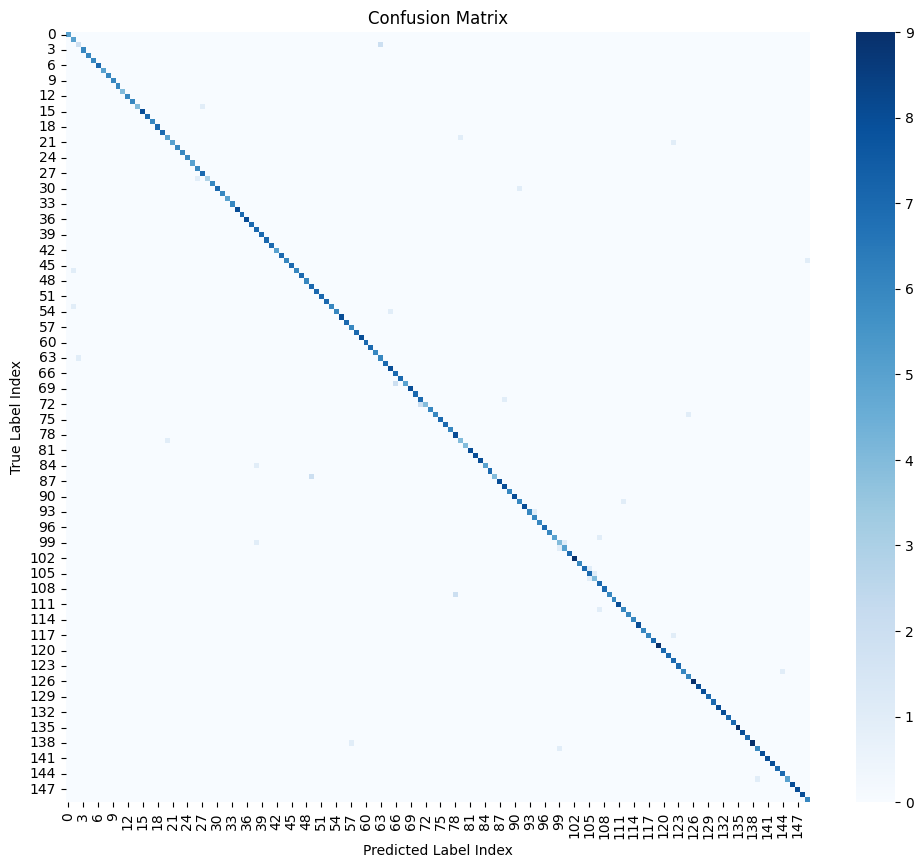

Evaluation complete


In [12]:
print('Starting evaluation...')
val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device, pokemon_class_names, detailed=False)
test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device, pokemon_class_names, detailed=True)
print('Evaluation complete')

,true_label,predicted_label,count
0,Machamp,Nidoqueen,1


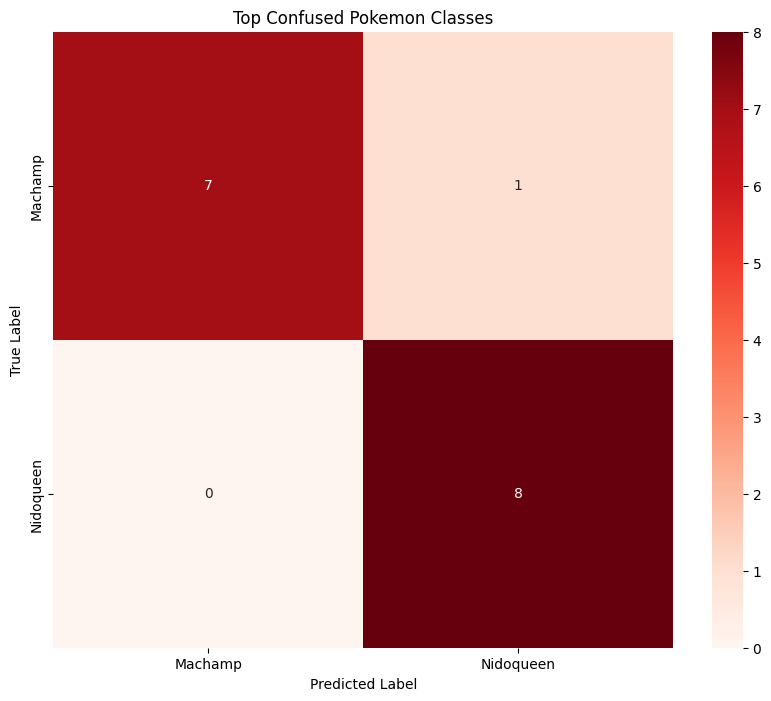

In [16]:
def analyze_top_confusions(model, data_loader, class_names, device, top_n=15, focus_classes=None):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(labels.cpu().numpy())

    confusion_df = pd.DataFrame(
        confusion_matrix(all_labels, all_predictions),
        index=class_names,
        columns=class_names,
    )

    confusion_pairs = []
    for true_name in class_names:
        for predicted_name in class_names:
            if true_name == predicted_name:
                continue
            count = int(confusion_df.loc[true_name, predicted_name])
            if count > 0:
                confusion_pairs.append({
                    'true_label': true_name,
                    'predicted_label': predicted_name,
                    'count': count,
                })

    if focus_classes is not None:
        focus_classes = set(focus_classes)
        confusion_pairs = [
            row for row in confusion_pairs
            if row['true_label'] in focus_classes or row['predicted_label'] in focus_classes
        ]

    top_confusions = pd.DataFrame(confusion_pairs).sort_values('count', ascending=False).head(top_n)

    if top_confusions.empty:
        print('No off-diagonal confusions found in this evaluation set.')
        return confusion_df, top_confusions

    display(top_confusions)

    labels_to_plot = sorted(set(top_confusions['true_label']).union(top_confusions['predicted_label']))
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_df.loc[labels_to_plot, labels_to_plot], annot=True, fmt='d', cmap='Reds')
    plt.title('Top Confused Pokemon Classes')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return confusion_df, top_confusions


confusion_df, top_confusions = analyze_top_confusions(
    model,
    test_loader,
    pokemon_class_names,
    device,
    top_n=15,
    focus_classes=['Nidoran', 'Nidorino', 'Nidorina', 'Nidoking', 'Nidoqueen'],
)

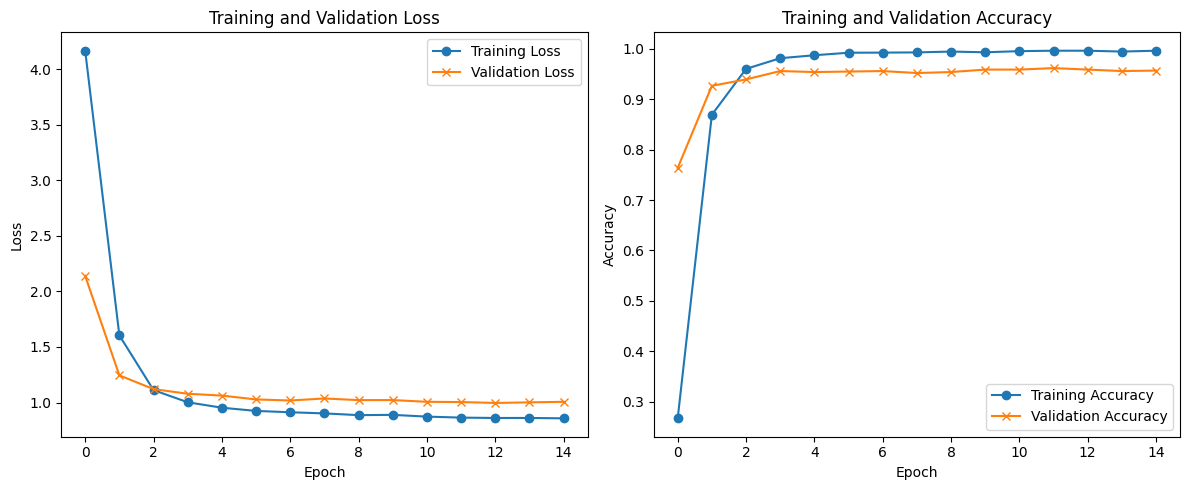

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Training Accuracy', marker='o')
plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

--- Sample Predictions ---


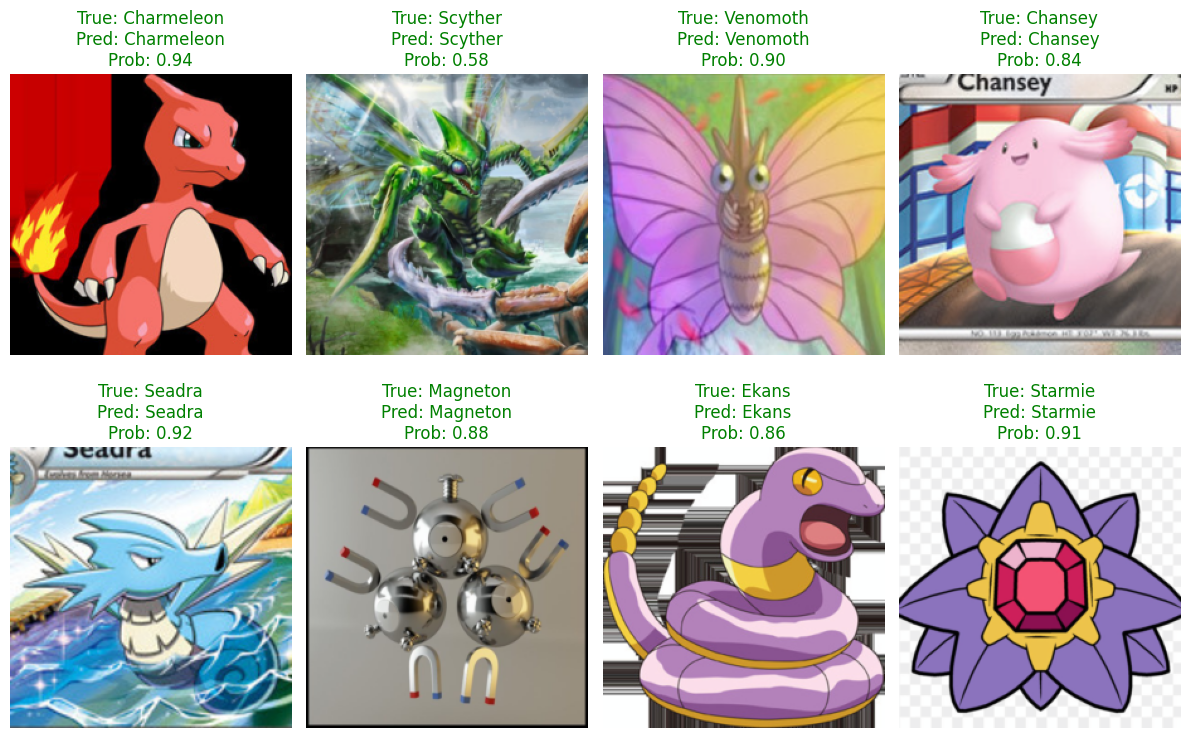

--- Misclassified Examples ---


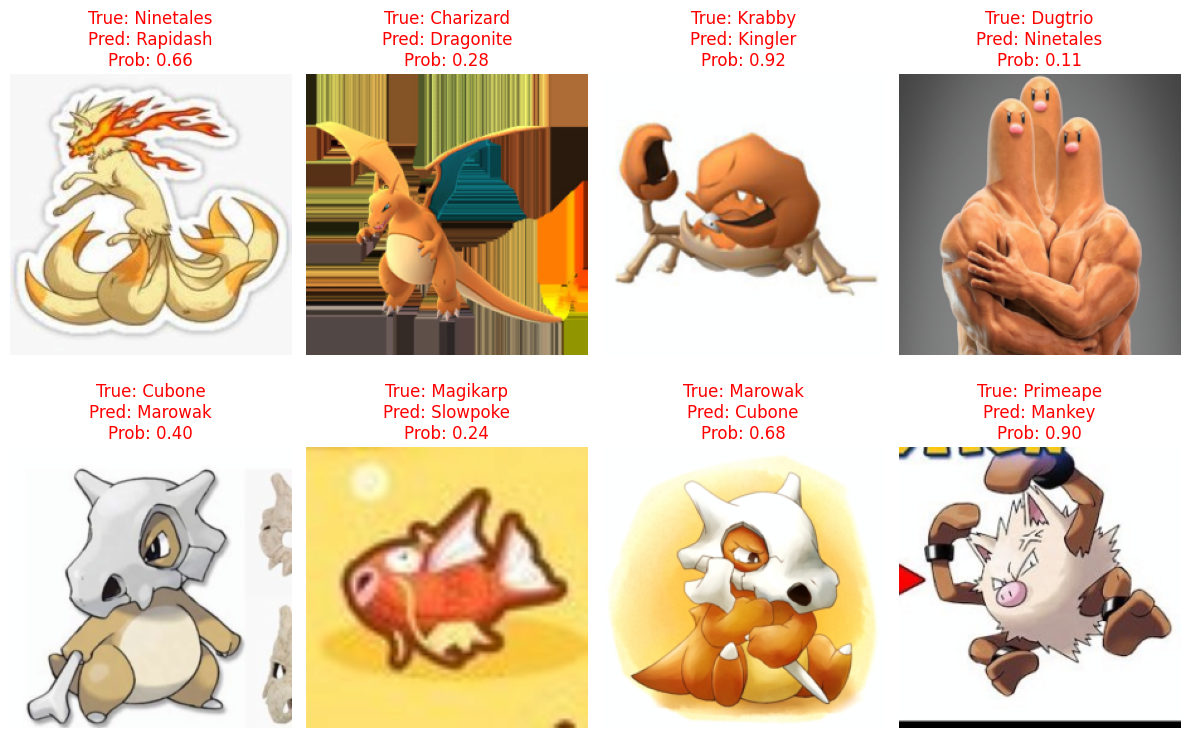

In [14]:
def show_sample_predictions(model, data_loader, class_names, device, num_samples=8):
    model.eval()
    images, labels = next(iter(data_loader))
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images[:num_samples])
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    plt.figure(figsize=(12, 8))
    for index in range(min(num_samples, len(images))):
        ax = plt.subplot(2, 4, index + 1)
        image = images[index].detach().cpu().permute(1, 2, 0).numpy()
        image = np.clip((image * std) + mean, 0, 1)
        predicted_idx = int(predictions[index].item())
        true_idx = int(labels[index].item())
        confidence = float(probabilities[index, predicted_idx].item())
        color = 'green' if predicted_idx == true_idx else 'red'
        ax.imshow(image)
        ax.set_title(
            f'True: {class_names[true_idx]}\nPred: {class_names[predicted_idx]}\nProb: {confidence:.2f}',
            color=color,
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_misclassified(model, data_loader, class_names, device, num_samples=8):
    model.eval()
    collected = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            probabilities = torch.softmax(outputs, dim=1)

            wrong_indices = torch.nonzero(predictions != labels, as_tuple=False).flatten()
            for wrong_index in wrong_indices:
                image = images[wrong_index].detach().cpu().permute(1, 2, 0).numpy()
                image = np.clip((image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406]), 0, 1)
                collected.append({
                    'image': image,
                    'true_idx': int(labels[wrong_index].item()),
                    'pred_idx': int(predictions[wrong_index].item()),
                    'confidence': float(probabilities[wrong_index, predictions[wrong_index]].item()),
                })
                if len(collected) >= num_samples:
                    break
            if len(collected) >= num_samples:
                break

    if not collected:
        print('No misclassified samples found in the inspected batches.')
        return

    plt.figure(figsize=(12, 8))
    for index, item in enumerate(collected, start=1):
        ax = plt.subplot(2, 4, index)
        ax.imshow(item['image'])
        ax.set_title(
            f"True: {class_names[item['true_idx']]}\nPred: {class_names[item['pred_idx']]}\nProb: {item['confidence']:.2f}",
            color='red',
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('--- Sample Predictions ---')
show_sample_predictions(model, test_loader, pokemon_class_names, device)
print('--- Misclassified Examples ---')
show_misclassified(model, test_loader, pokemon_class_names, device)

In [15]:
print('--- Model Performance Summary ---')
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
print(f"Final training accuracy: {history['train_accuracy'][-1]:.4f}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_accuracy'][-1]:.4f}")
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

if MODEL_PATH.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_path = MODEL_PATH.with_name(f'{MODEL_PATH.stem}_{timestamp}{MODEL_PATH.suffix}')
    shutil.copy2(MODEL_PATH, backup_path)
    print(f'Backed up previous model to {backup_path}')

torch.save(model.state_dict(), MODEL_PATH)
print(f'Saved model to {MODEL_PATH}')

--- Model Performance Summary ---
Final training loss: 0.8579
Final training accuracy: 0.9964
Final validation loss: 1.0066
Final validation accuracy: 0.9570
Test loss: 0.9868
Test accuracy: 0.9619
Backed up previous model to pokemon_model_gen1_resnet50_20260912_212600.pth
Saved model to pokemon_model_gen1_resnet50.pth
